In [51]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import json

# Dependency:
* DDBC
* DDBC_MSIGDB

# Loading variables

In [52]:
DISEASE = input("Disease: ")
OUTPUT_DIRECTORY = f"../output/{DISEASE}/"
NONE_OUTPUT_DIRECTORY  = f"../output/NONE/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"
MSIGDB_DIRECTORY = f"../../Gen_Hypergraph/output/MSIGDB_FULL/"

In [53]:
with open(f"{DGIDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    dgidb_gene_to_index = json.load(f)
with open(f"{MSIGDB_DIRECTORY}/gene_to_index.json", "rb") as f:
    msigdb_gene_to_index = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/gene_to_index_distinct.json", "rb") as f:
    gene_to_index_distinct = json.load(f)
with open(f"{OUTPUT_DIRECTORY}/dgidb_ori_idx.pkl", "rb") as f:
    dgidb_ori_idx = pickle.load(f)
with open(f"{OUTPUT_DIRECTORY}/dgidb_agg_idx.pkl", "rb") as f:
    dgidb_agg_idx = pickle.load(f)

In [54]:
num_add_rows = (len(dgidb_agg_idx) - len(dgidb_ori_idx))

In [55]:
num_add_rows

10

In [56]:
print(len(dgidb_ori_idx))
print(len(dgidb_agg_idx))

349
359


In [57]:
## Sanity Check
index_to_gene_distinct = {v: k for k, v in gene_to_index_distinct.items()}
dgidb_index_to_gene = {v: k for k, v in dgidb_gene_to_index.items()}
msigdb_index_to_gene = {v: k for k, v in msigdb_gene_to_index.items()}

for i in range(len(dgidb_agg_idx)):
    gene_name = index_to_gene_distinct[dgidb_agg_idx[i]]
    p = dgidb_gene_to_index.get(gene_name, None)
    assert p is not None

for i in range(len(dgidb_ori_idx)):
    gene_name = msigdb_index_to_gene[dgidb_ori_idx[i]]
    p = dgidb_gene_to_index.get(gene_name, None)
    assert p is not None

In [58]:
# load selected communities
with open(f"{OUTPUT_DIRECTORY}/ddm_agg.pkl", "rb") as f:
    ddm_both = pickle.load(f)

In [59]:
# load npy arrays for NONE
ddm_msigdb = np.load(f"{NONE_OUTPUT_DIRECTORY}/diffusion_dist_matrices/ddm.npy")

In [60]:
# crop the distinct dgidb genes
dgidb_agg_idx = [u + num_add_rows for u in dgidb_ori_idx]

In [61]:
dgidb_ori_idx

[672,
 8137,
 1295,
 10041,
 185,
 2332,
 1114,
 2004,
 1125,
 4685,
 7192,
 12561,
 6408,
 32,
 8817,
 6191,
 5442,
 10588,
 1113,
 5162,
 5986,
 11418,
 6657,
 827,
 4362,
 7916,
 5254,
 5,
 104,
 2159,
 1128,
 0,
 7996,
 2,
 4369,
 10563,
 2034,
 2358,
 992,
 72,
 15207,
 4364,
 3738,
 12983,
 10574,
 514,
 5161,
 3035,
 2176,
 1996,
 1126,
 2000,
 2129,
 1741,
 1735,
 1737,
 1747,
 2327,
 2329,
 2338,
 106,
 273,
 5029,
 1863,
 1296,
 1,
 1820,
 1813,
 3069,
 1123,
 1729,
 3328,
 3863,
 3327,
 18220,
 434,
 3238,
 2174,
 10589,
 10242,
 1749,
 1294,
 1297,
 10565,
 1987,
 2008,
 2334,
 16,
 154,
 156,
 2173,
 2335,
 1133,
 107,
 1748,
 5037,
 2028,
 2157,
 10587,
 8134,
 10566,
 3623,
 2330,
 105,
 186,
 1798,
 826,
 2128,
 831,
 1536,
 2339,
 1010,
 4697,
 20690,
 12450,
 18,
 9456,
 1742,
 2328,
 14,
 157,
 673,
 3608,
 73,
 2280,
 340,
 7858,
 1560,
 2439,
 10562,
 17716,
 15206,
 7328,
 1408,
 640,
 3814,
 2166,
 2899,
 16969,
 15,
 2158,
 4501,
 6680,
 2741,
 2551,
 8276,
 181

In [62]:
dgidb_agg_idx

[682,
 8147,
 1305,
 10051,
 195,
 2342,
 1124,
 2014,
 1135,
 4695,
 7202,
 12571,
 6418,
 42,
 8827,
 6201,
 5452,
 10598,
 1123,
 5172,
 5996,
 11428,
 6667,
 837,
 4372,
 7926,
 5264,
 15,
 114,
 2169,
 1138,
 10,
 8006,
 12,
 4379,
 10573,
 2044,
 2368,
 1002,
 82,
 15217,
 4374,
 3748,
 12993,
 10584,
 524,
 5171,
 3045,
 2186,
 2006,
 1136,
 2010,
 2139,
 1751,
 1745,
 1747,
 1757,
 2337,
 2339,
 2348,
 116,
 283,
 5039,
 1873,
 1306,
 11,
 1830,
 1823,
 3079,
 1133,
 1739,
 3338,
 3873,
 3337,
 18230,
 444,
 3248,
 2184,
 10599,
 10252,
 1759,
 1304,
 1307,
 10575,
 1997,
 2018,
 2344,
 26,
 164,
 166,
 2183,
 2345,
 1143,
 117,
 1758,
 5047,
 2038,
 2167,
 10597,
 8144,
 10576,
 3633,
 2340,
 115,
 196,
 1808,
 836,
 2138,
 841,
 1546,
 2349,
 1020,
 4707,
 20700,
 12460,
 28,
 9466,
 1752,
 2338,
 24,
 167,
 683,
 3618,
 83,
 2290,
 350,
 7868,
 1570,
 2449,
 10572,
 17726,
 15216,
 7338,
 1418,
 650,
 3824,
 2176,
 2909,
 16979,
 25,
 2168,
 4511,
 6690,
 2751,
 2561,
 8286,

# diffusion distance comparison

In [63]:
# average of each row
ddm_multilayer_avg    = np.asarray(np.mean(ddm_both, axis=1)).ravel()
ddm_singlelayer_avg = np.asarray(np.mean(ddm_msigdb, axis=1)).ravel()
ddm_multilayer_avg_DGIDB    = np.asarray(np.mean(ddm_both[:,dgidb_agg_idx], axis=1)).ravel()
ddm_singlelayer_avg_DGIDB = np.asarray(np.mean(ddm_msigdb[:,dgidb_ori_idx], axis=1)).ravel()

In [64]:
# align the two arrays by length
print(len(ddm_multilayer_avg), len(ddm_singlelayer_avg))

21991 21981


In [65]:
average_diff_dist_DGIDB_MSIGDB_singlelayer = np.asarray([ddm_singlelayer_avg[u] for u in dgidb_ori_idx])
average_diff_dist_DGIDB_DGIDB_singlelayer = np.asarray([ddm_singlelayer_avg_DGIDB[u] for u in dgidb_agg_idx])
average_diff_dist_MSIGDB_MSIGDB_singlelayer = np.asarray(ddm_singlelayer_avg)

In [66]:
average_diff_dist_DGIDB_MSIGDB_multilayer = np.asarray([ddm_multilayer_avg[u] for u in dgidb_agg_idx])
average_diff_dist_DGIDB_DGIDB_multilayer = np.asarray([ddm_multilayer_avg_DGIDB[u] for u in dgidb_agg_idx])
average_diff_dist_MSIGDB_MSIGDB_multilayer = np.asarray(ddm_multilayer_avg[num_add_rows:])

In [67]:
print(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
print(len(average_diff_dist_DGIDB_MSIGDB_multilayer))
print(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
print(len(average_diff_dist_DGIDB_DGIDB_multilayer))

349
349
349
349


In [68]:
# setting universal font sizes
font_size = 25
tick_font_size = 16
plt.rcParams.update({
    "font.size": font_size,          # base font size
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


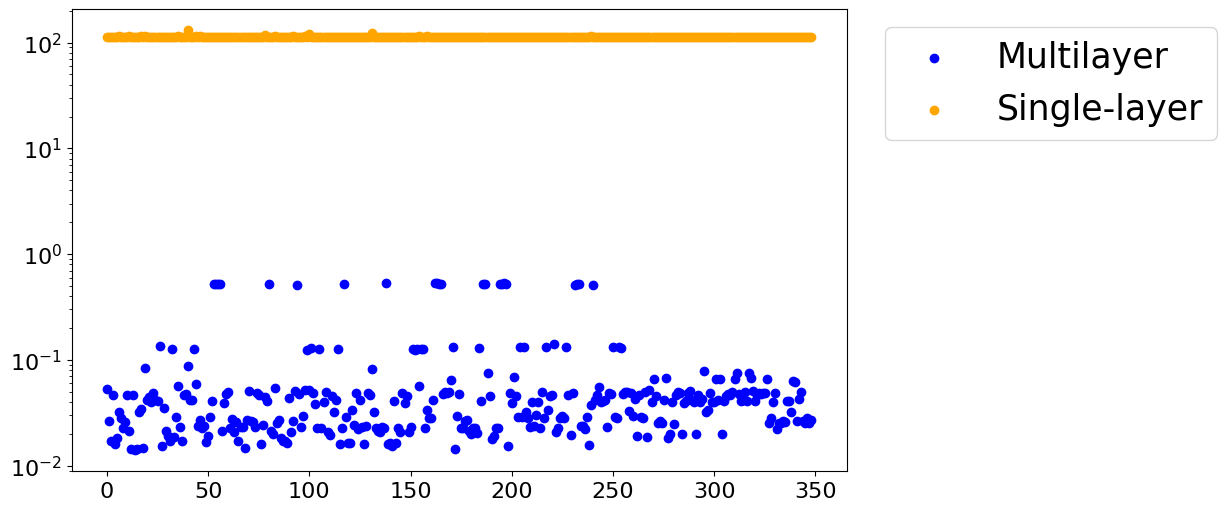

In [69]:
# DGIDB rows comparing to all genes
xaxis = range(len(average_diff_dist_DGIDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_comp.png", bbox_inches='tight')

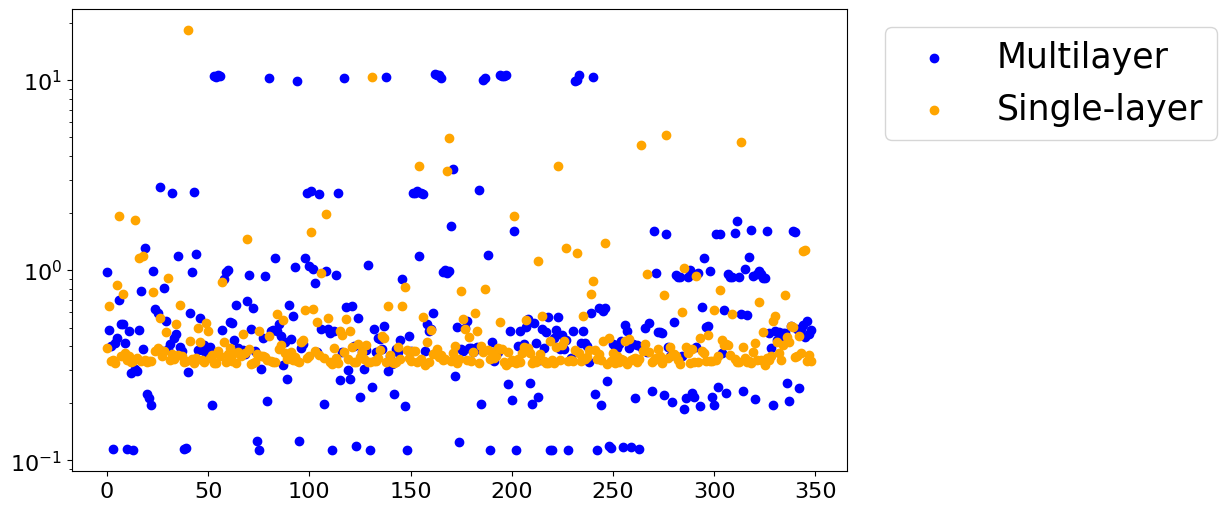

In [70]:
# DGIDB rows comparing to DGIDB genes
xaxis = range(len(average_diff_dist_DGIDB_DGIDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_DGIDB_DGIDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_DGIDB_comp.png", bbox_inches='tight')

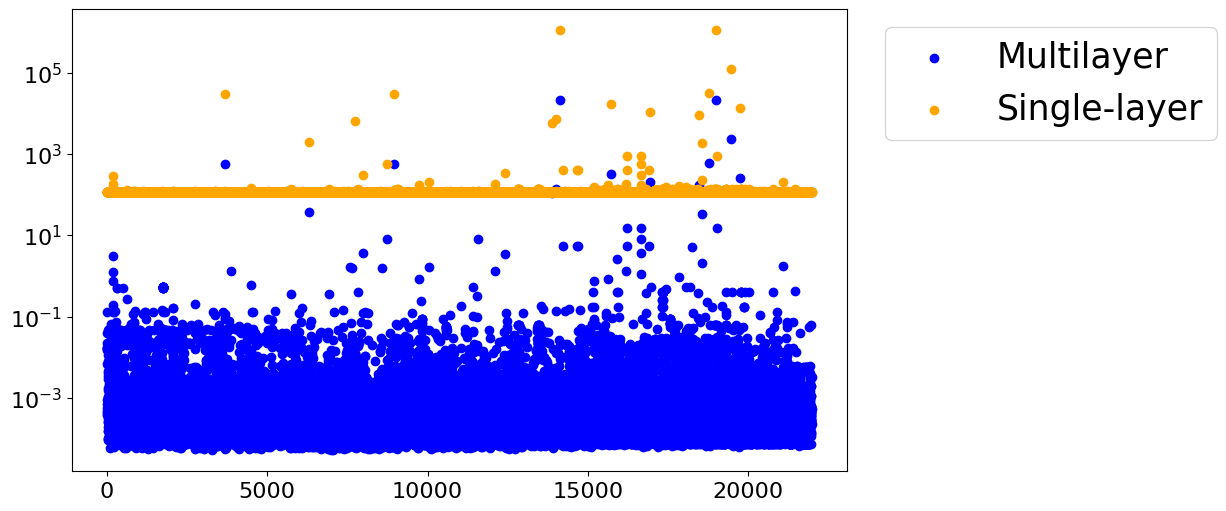

In [71]:
# all rows comparing to all genes
xaxis = range(len(average_diff_dist_MSIGDB_MSIGDB_singlelayer))
plt.figure(figsize=(10, 6))
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_multilayer, label='Multilayer', color='blue')
plt.scatter(xaxis, average_diff_dist_MSIGDB_MSIGDB_singlelayer, label='Single-layer', color='orange')
plt.yscale('log')
# legend placed outside of plot
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_MSIGDB_MSIGDB_comp.png", bbox_inches='tight')

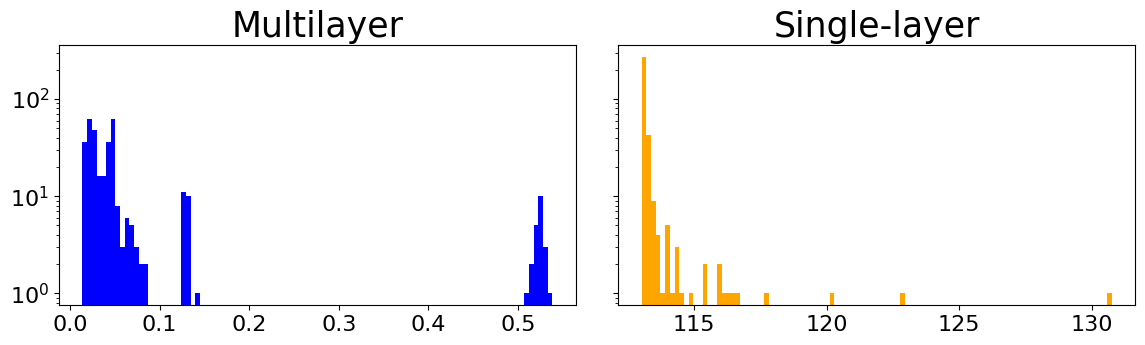

In [72]:
# DGIDB rows comparing to all genes - Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax in axes:
    ax.set_yscale("log")

axes[0].hist(average_diff_dist_DGIDB_MSIGDB_multilayer, bins=100, color='blue')
axes[0].set_title("Multilayer")

axes[1].hist(average_diff_dist_DGIDB_MSIGDB_singlelayer, bins=100, color='orange')
axes[1].set_title("Single-layer")

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/diff_dist_DGIDB_MSIGDB_histogram.png", bbox_inches='tight')
plt.show()



In [80]:
diff_dist_stat = {
    "DGIDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_singlelayer.var())},
    "DGIDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_DGIDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_MSIGDB_multilayer.var())},
    "DGIDB_DGIDB_singlelayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_singlelayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_singlelayer.var())},
    "DGIDB_DGIDB_multilayer": {"mean": float(average_diff_dist_DGIDB_DGIDB_multilayer.mean()), "var": float(average_diff_dist_DGIDB_DGIDB_multilayer.var())},
    "MSIGDB_MSIGDB_singlelayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_singlelayer.var())},
    "MSIGDB_MSIGDB_multilayer": {"mean": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.mean()), "var": float(average_diff_dist_MSIGDB_MSIGDB_multilayer.var())},
}

In [82]:
with open(f"../../Graphs/{DISEASE}/diff_dist_stat.json", "w") as f:
    json.dump(diff_dist_stat, f, indent=4)

In [47]:
# plt.figure(figsize=(10, 6))
# plt.hist([ddm_msigdb_avg,ddm_both_avg_cropped], color=['orange', 'blue'], bins = 1000)
# # plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# # plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot
# plt.legend(['Single-layer', 'Multilayer'], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=17)

In [48]:
# diff = ddm_both_avg_cropped / ddm_msigdb_avg

# plt.figure(figsize=(10, 6))
# plt.hist(diff, color='orange', bins = 1000)
# plt.axvline(1, color="black", linestyle="--", linewidth=2, label="baseline = 1")
# plt.xlabel("Ratio of Average Diffusion Distances (Multilayer / Single-layer)", fontsize=17)
# plt.ylabel("Count", fontsize=17)
# plt.yscale('log')
# # legend placed outside of plot